In [1]:
import os
import geopandas as gpd
from geomap import Map
import pandas as pd
from matplotlib import pyplot as plt
from dataprocess import kringing

In [2]:
params_name = [
    "P",
    "K",
    "N",
    "Cr",
    "Cu",
    "Zn",
    "As",
    "Cd",
    "Pb",
    "Se",
    "Mo",
    "Na",
    "Al",
    "Si",
    "Ca",
    "Fe",
    "Hg",
    "La",
    "Mg",
    "Mn",
    "有效态Cd",
    "水稻Cd",
]

file_path_shp = os.path.join(".", "数据", "湘潭县界.shp")


kringing(pd.read_excel(os.path.join(".", "数据", "水稻点位148.xlsx")),params_name, 20)


file_path_df = os.path.join(".", "数据", "水稻点位148.xlsx")

file_path_kringing = os.path.join(".", "kringing", "data.xlsx")

c:\Codes\agricultural-decision-system\.venv\lib\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


插值数据保存成功！


c:\Codes\agricultural-decision-system\.venv\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: '有效态Cd' to '有效态C'
  ogr_write(


In [3]:
map = Map(file_path_shp)

In [4]:
map.gdf

,县代码,省代码,市代码,县名称,市名称,省名称,xcode,经1,经2,纬1,纬2,geometry
0,430321,430000,430300,湘潭县,湘潭市,湖南省,430321.0,112.421278,113.058939,27.338039,27.94195,"POLYGON ((112.64099 27.87982, 112.6438 27.8796..."


In [5]:
map.load_dots_df(pd.read_excel(file_path_kringing))
map.load_dots_df(pd.read_excel(file_path_df))
grid = map.grid_paint(20,20)
grid.set_focus()

<Axes: >

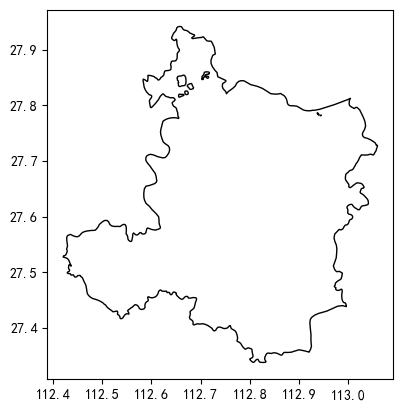

In [6]:
fig, ax = plt.subplots()
map.gdf.boundary.plot(ax=ax, color="black", linewidth=1)

In [7]:
grid.set_value_matrix("N")

In [8]:
bounds = map.outline.bounds
bounds = [bounds[0],bounds[2],bounds[1],bounds[3]]

img = ax.imshow(map.grid.value_matrix, extent=bounds, origin="lower", alpha=0.5)

In [9]:
ax.set_xlim(bounds[:2])
ax.set_ylim(bounds[2:])
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

fig.colorbar(img, ax=ax)

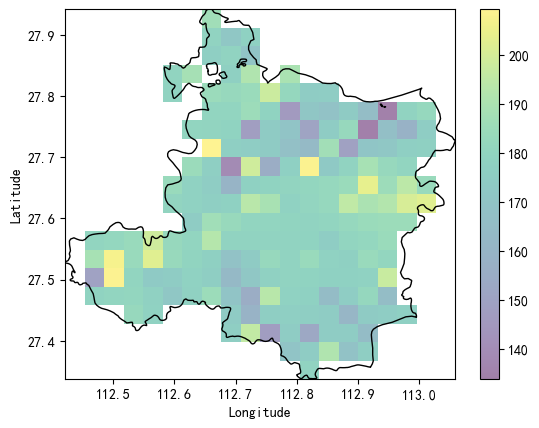

In [10]:
fig

In [11]:
plt.show()

In [12]:
fig.savefig("./Images/img.png")